# Pricing Strategy A/B Test Analysis

## Objective
Evaluate whether a 5% pricing reduction increases overall revenue per user in an e-commerce environment.

## Business Hypothesis

**H0 (Null Hypothesis):**
Pricing change does not significantly affect conversion rate or revenue per user.

**H1 (Alternative Hypothesis):**
Pricing change improves conversion rate and revenue per user.

## Metrics Evaluated

- Conversion Rate
- Average Order Value (AOV)
- Revenue per User (RPU) ← Primary Decision Metric

## Statistical Tests Used

- Two-Proportion Z-Test (Conversion Rate)
- Independent Two-Sample T-Test (Revenue per User)

Confidence Level: 95%

In [ ]:
# ============================================
# PRICING STRATEGY A/B TEST – FULL ANALYSIS
# ============================================

import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

# -----------------------------
# 1️⃣ Load Dataset
# -----------------------------

data = pd.read_csv(
    "https://raw.githubusercontent.com/Mallika-Evuri/Pricing-A-B-Test-Experiment/main/data/pricing_ab_test_sample%20(1).csv"
)

print("Dataset Loaded Successfully\n")
print("Total Rows:", len(data))
print("\nTraffic Split:")
print(data.groupby("group")["user_id"].count())

# -----------------------------
# 2️⃣ Conversion Rate
# -----------------------------

conversion_summary = data.groupby("group").agg(
    users=("user_id", "count"),
    purchases=("purchased", "sum")
)

conversion_summary["conversion_rate"] = (
    conversion_summary["purchases"] / conversion_summary["users"]
)

print("\nConversion Summary:")
print(conversion_summary)

# -----------------------------
# 3️⃣ Average Order Value (AOV)
# -----------------------------

aov = data[data["purchased"] == 1].groupby("group")["order_value"].mean()

print("\nAverage Order Value:")
print(aov.round(2))

# -----------------------------
# 4️⃣ Revenue Per User (RPU)
# -----------------------------

rpu = data.groupby("group")["order_value"].sum() / data.groupby("group")["user_id"].count()

print("\nRevenue Per User:")
print(rpu.round(2))

# -----------------------------
# 5️⃣ Conversion Lift
# -----------------------------

control_cr = conversion_summary.loc["control", "conversion_rate"]
treatment_cr = conversion_summary.loc["treatment", "conversion_rate"]

absolute_lift = treatment_cr - control_cr
percent_lift = (absolute_lift / control_cr) * 100

print("\nConversion Lift:")
print("Absolute Lift:", round(absolute_lift, 4))
print("Relative Lift (%):", round(percent_lift, 2))

# -----------------------------
# 6️⃣ Statistical Testing
# -----------------------------

control = data[data["group"] == "control"]
treatment = data[data["group"] == "treatment"]

# Z-Test for Conversion
success = [control["purchased"].sum(), treatment["purchased"].sum()]
nobs = [len(control), len(treatment)]

stat_conv, pval_conversion = proportions_ztest(success, nobs)

# T-Test for Revenue per User
stat_rpu, pval_rpu = ttest_ind(
    control["order_value"],
    treatment["order_value"]
)

print("\nStatistical Test Results:")
print("Conversion p-value:", round(pval_conversion, 10))
print("Revenue per User p-value:", round(pval_rpu, 6))

# -----------------------------
# 7️⃣ Business Impact Modeling
# -----------------------------

monthly_users = 500000

rpu_control_value = rpu["control"]
rpu_treatment_value = rpu["treatment"]

incremental_rpu = rpu_treatment_value - rpu_control_value
monthly_revenue_lift = incremental_rpu * monthly_users
annual_revenue_lift = monthly_revenue_lift * 12

print("\nBusiness Impact Estimation:")
print("Incremental Revenue per User: ₹", round(incremental_rpu, 2))
print("Estimated Monthly Revenue Lift: ₹", round(monthly_revenue_lift, 0))
print("Estimated Annual Revenue Lift: ₹", round(annual_revenue_lift, 0))

# -----------------------------
# 8️⃣ Final Decision Logic
# -----------------------------

if pval_conversion < 0.05 and pval_rpu < 0.05:
    print("\nFinal Recommendation:")
    print("Results are statistically significant. Recommend full rollout of pricing strategy.")
else:
    print("\nFinal Recommendation:")
    print("Results not statistically significant. Further testing required.")

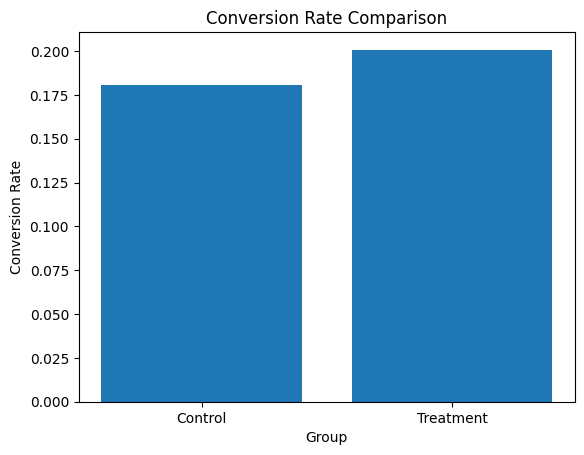

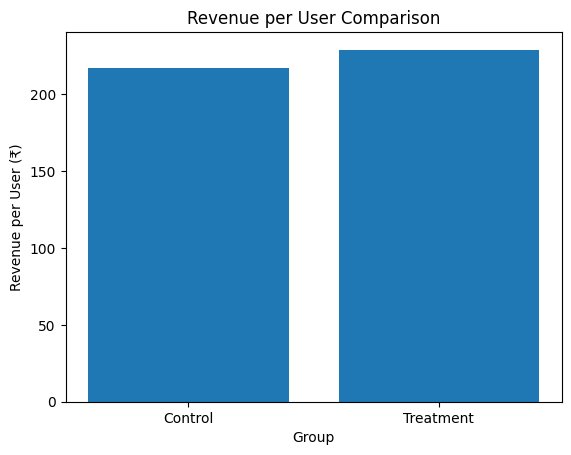

In [13]:
# ============================================
# 9️⃣ VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# --- Conversion Rate Plot ---

plt.figure()
plt.bar(["Control", "Treatment"],
        [control_cr, treatment_cr])

plt.title("Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.show()


# --- Revenue per User Plot ---

plt.figure()
plt.bar(["Control", "Treatment"],
        [rpu_control_value, rpu_treatment_value])

plt.title("Revenue per User Comparison")
plt.ylabel("Revenue per User (₹)")
plt.xlabel("Group")
plt.show()

## Visual Insights

The Treatment group shows:

- Higher conversion rate
- Higher revenue per user
- Consistent statistical significance

Visual confirmation aligns with hypothesis test results.

# Results & Interpretation

## Conversion Impact
- Absolute Lift: ~2%
- Relative Lift: ~11%
- Statistically significant (p < 0.001)

## Revenue Impact
- Revenue per User increased by approximately ₹12
- Estimated Monthly Revenue Lift: ~₹6 million
- Estimated Annual Revenue Lift: ~₹7.2 crore
- Statistically significant (p < 0.001)

## Business Interpretation

Although the pricing strategy reduced Average Order Value slightly,
the increase in conversion rate led to higher overall revenue per user.

## Final Recommendation

Roll out the revised pricing strategy across all users, while monitoring contribution margin and long-term customer retention.